# Stage 4+5: PCA plane geometry, radius/perp, and drift & variability

Two subphases in one notebook, per the plan:
- **Subphase 4**: draw the fitted PCA plane (center/e1/e2/normal) for representative
  cycles with the real 3-D data on it, plus full-block radius/perp/phase time series.
- **Subphase 5**: within-block (cycle-to-cycle) and across-run (bout-to-bout,
  day-1-start vs day-3-end) drift/variability summaries.

Everything here reads from Stage 2's cache (`cache/pca_results.pkl`) — nothing is refit.

In [7]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)

import _plotting as pl
from _loading import load_block

with open("cache/pca_results.pkl", "rb") as f:
    CACHE = pickle.load(f)

def cache_index():
    rows = []
    for k, v in CACHE.items():
        subject, day, part, skill, source_file, run_id, hand = k
        m = v["meta"]
        rows.append({"key": k, "subject": subject, "day": day, "part": part, "skill": skill,
                     "source_file": source_file, "run_id": run_id, "hand": hand,
                     "run_duration_sec": m["run_duration_sec"], "n_cycles": m["n_cycles"]})
    return pd.DataFrame(rows)

IDX = cache_index()
print(f"{len(IDX)} cached run x hand fits")

CONDITIONS = [(1, "s", "walk"), (1, "s", "jump"), (1, "s", "climb"),
              (3, "e", "walk"), (3, "e", "jump"), (3, "e", "climb")]

def primary_key(day, part, skill, hand="r_hand"):
    sub = IDX[(IDX.day == day) & (IDX.part == part) & (IDX.skill == skill) & (IDX.hand == hand)]
    return sub.loc[sub.run_duration_sec.idxmax(), "key"]

PRIMARY_KEYS = {cond: primary_key(*cond) for cond in CONDITIONS}
PRIMARY_HAND = "r_hand"

for cond, k in PRIMARY_KEYS.items():
    m = CACHE[k]["meta"]
    print(cond, "-> run_id", k[5], f"n_cycles={m['n_cycles']}", f"duration={m['run_duration_sec']:.2f}s")

116 cached run x hand fits
(1, 's', 'walk') -> run_id 1 n_cycles=26 duration=25.98s
(1, 's', 'jump') -> run_id 1 n_cycles=10 duration=8.98s
(1, 's', 'climb') -> run_id 6 n_cycles=20 duration=22.98s
(3, 'e', 'walk') -> run_id 9 n_cycles=23 duration=14.98s
(3, 'e', 'jump') -> run_id 5 n_cycles=41 duration=30.98s
(3, 'e', 'climb') -> run_id 5 n_cycles=39 duration=28.98s


## Subphase 4a — PCA plane geometry

For each of the 6 primary (longest-per-condition) blocks and both hands, three
representative *interior* cycles (second, middle, penultimate fitted cycle) are drawn.
This avoids partial cycles at the boundaries of a movement run. Each fitted plane is a
translucent surface spanned by `e1`/`e2` over that cycle's observed `(u, v)` range, with
the measured 3-D hand-relative-to-root points overlaid. Point color progresses from
purple to yellow over within-cycle time, making the direction of travel explicit.

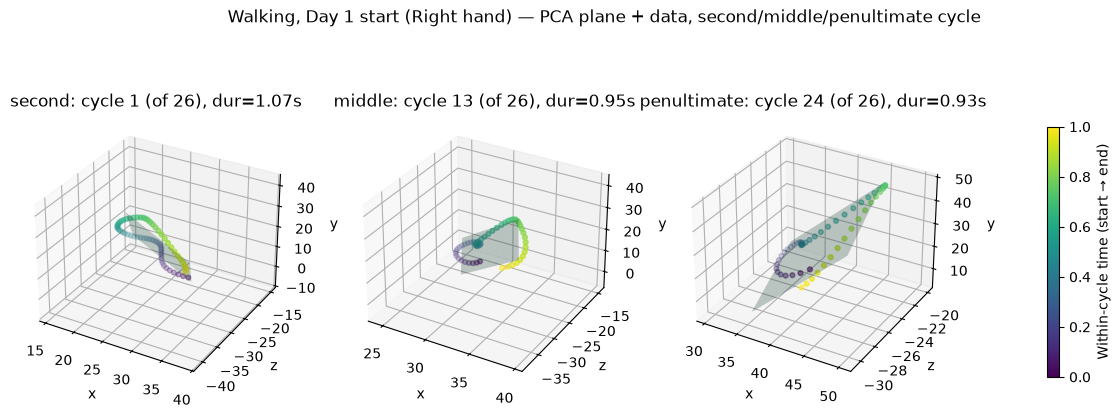

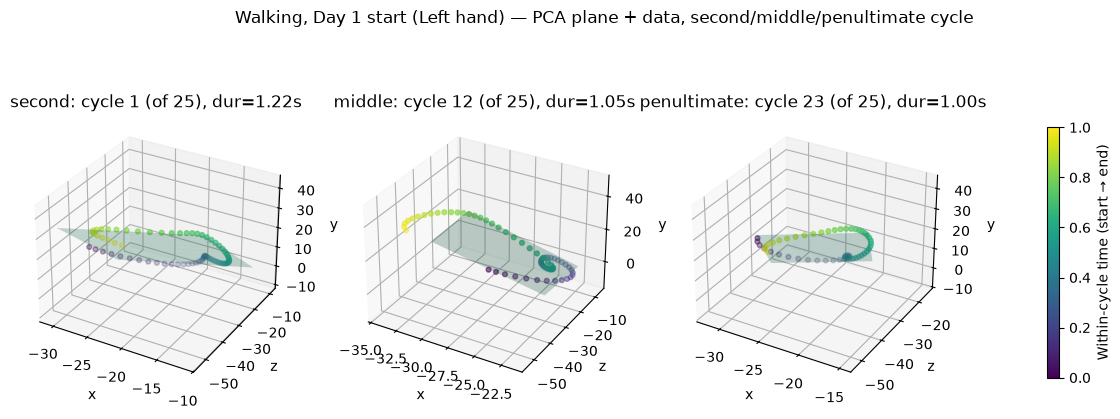

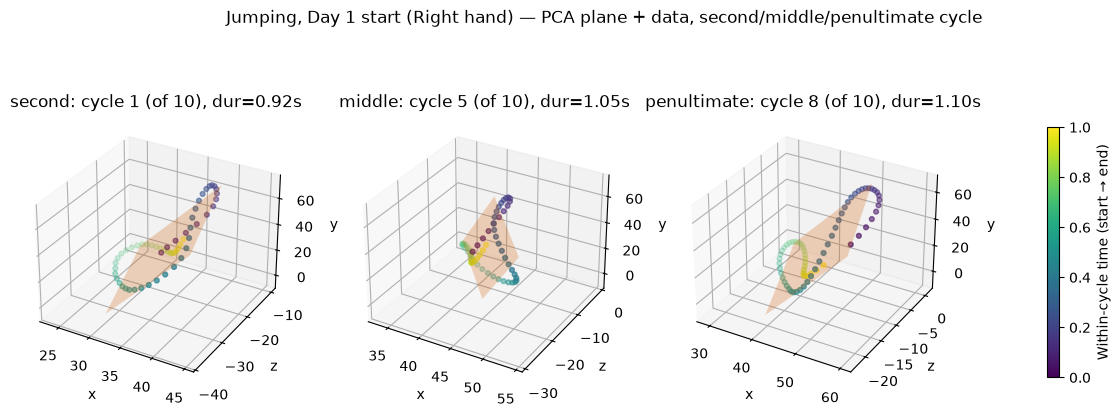

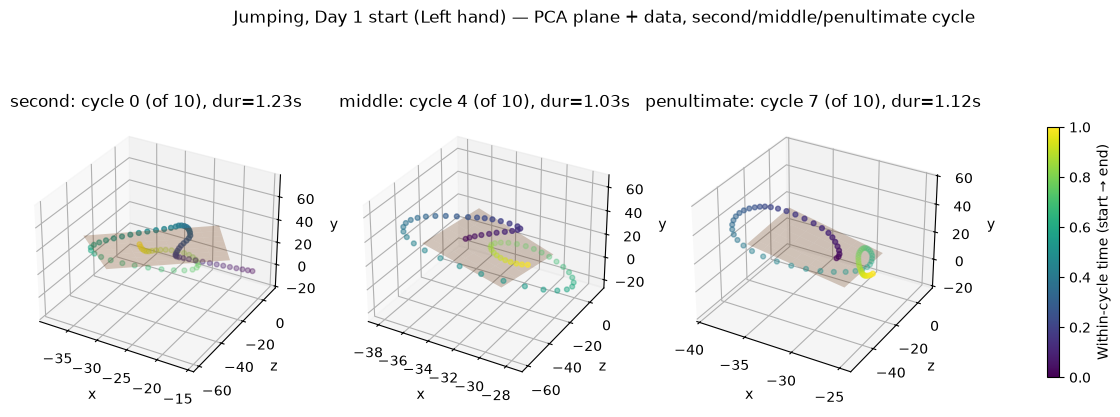

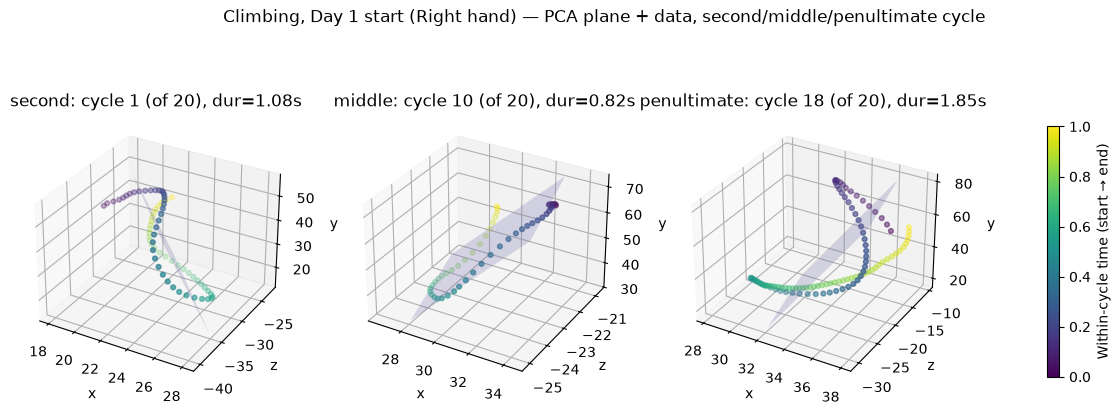

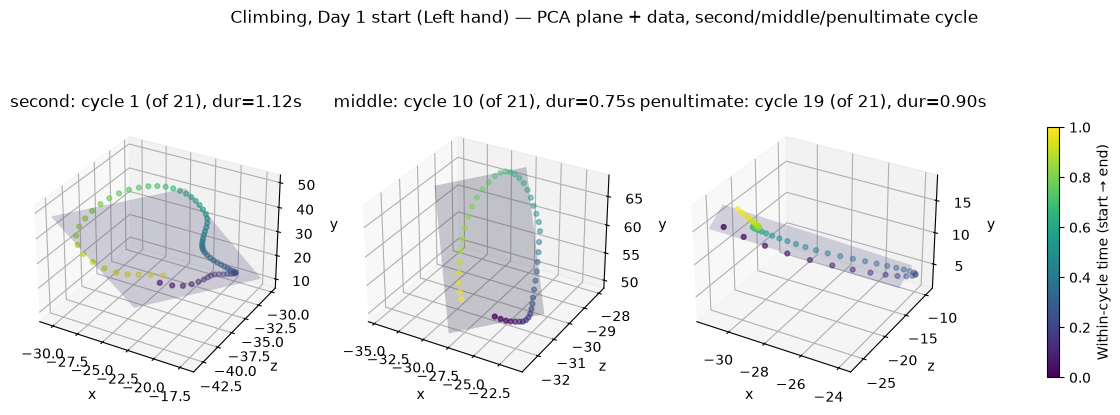

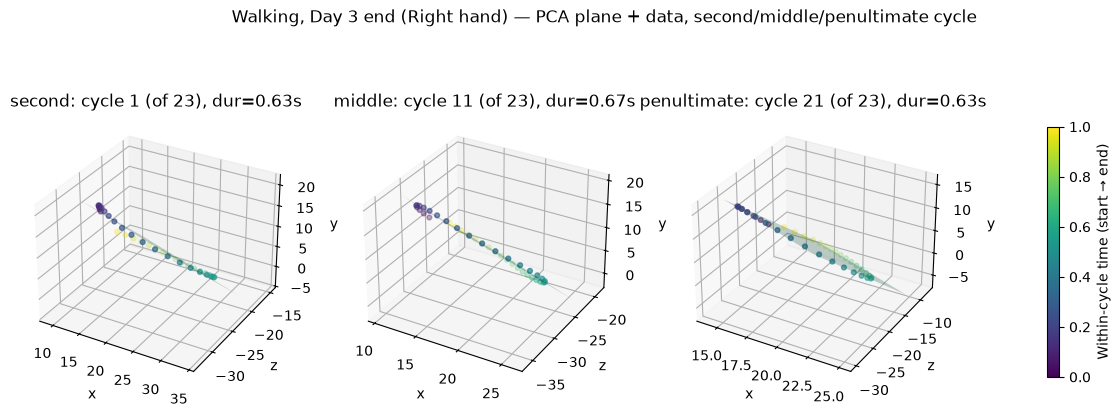

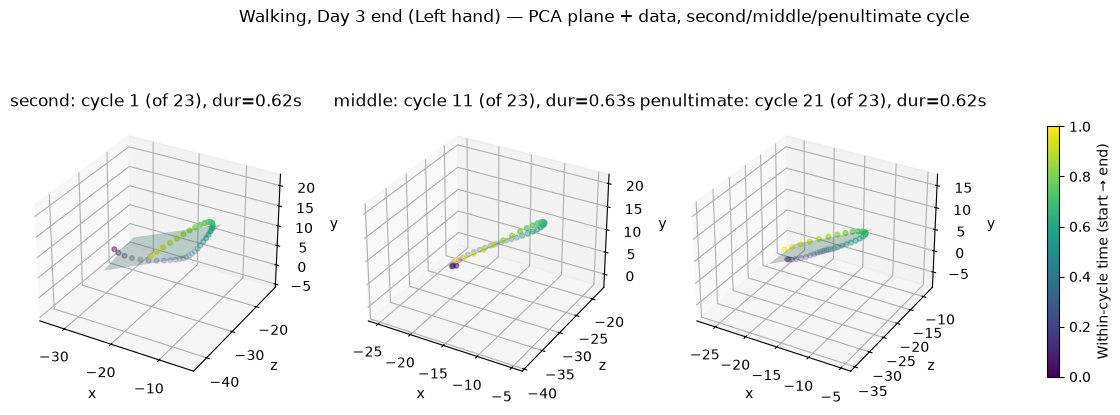

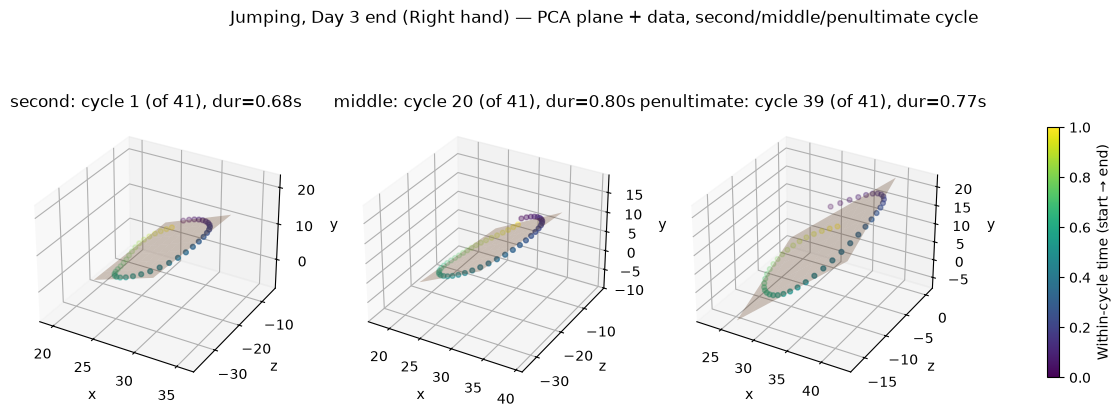

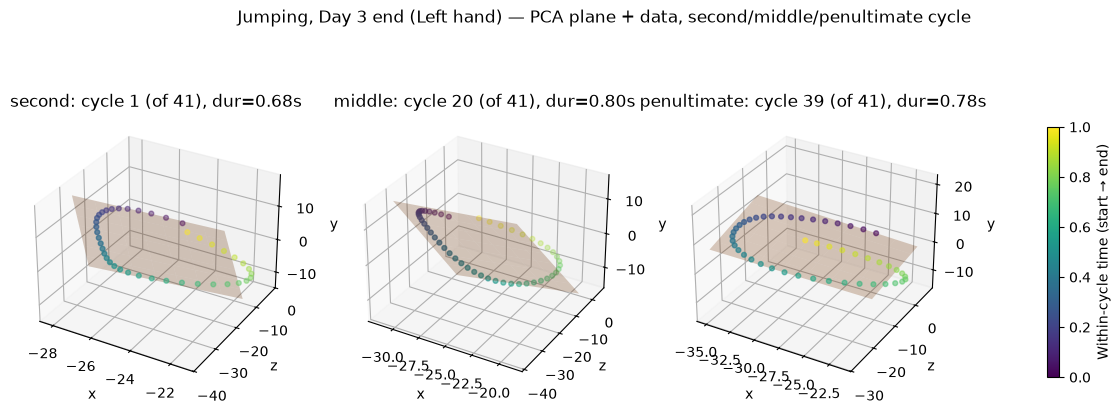

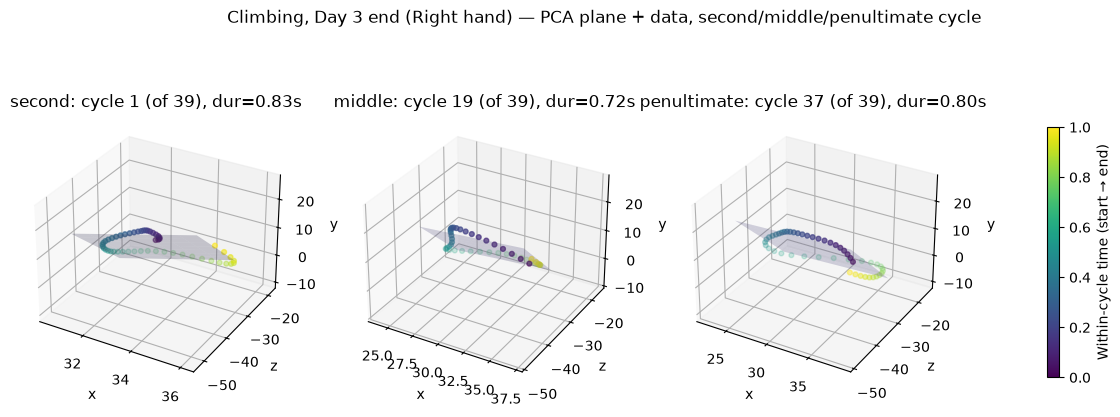

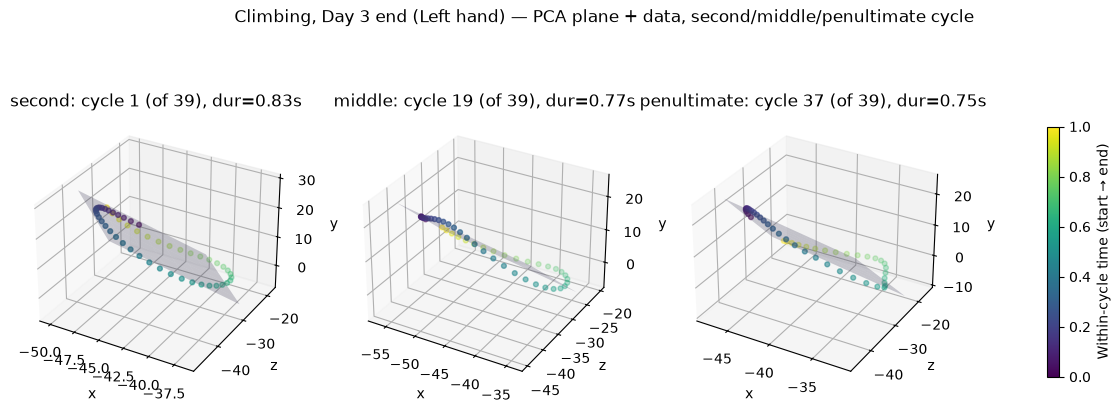

In [8]:
def plane_grid(cyc, u_range, v_range, n=8):
    c = np.array([cyc.center_x, cyc.center_y, cyc.center_z])
    e1 = np.array([cyc.e1_x, cyc.e1_y, cyc.e1_z])
    e2 = np.array([cyc.e2_x, cyc.e2_y, cyc.e2_z])
    uu, vv = np.meshgrid(np.linspace(*u_range, n), np.linspace(*v_range, n))
    grid = c[None, None, :] + uu[..., None] * e1[None, None, :] + vv[..., None] * e2[None, None, :]
    return grid[..., 0], grid[..., 1], grid[..., 2]


def plot_block_planes(cond, key, hand):
    entry = CACHE[key]
    cycles, samples = entry["cycles"], entry["samples"]
    day, part, skill = cond
    X, cols, meta = load_block(meta_subject := entry["meta"]["subject"], day, part, skill,
                                run_index="longest", hand=hand)
    ok = cycles[cycles.fit_ok].reset_index(drop=True)
    if len(ok) < 3:
        print(f"{cond} {hand}: fewer than three fitted cycles, skipping")
        return
    pick_idx = [1, len(ok) // 2, len(ok) - 2]
    pick_labels = ["second", "middle", "penultimate"]
    fig = plt.figure(figsize=(5.2 * len(pick_idx), 5))
    color = pl.SKILL_COLORS[skill]
    for j, (i, label) in enumerate(zip(pick_idx, pick_labels)):
        cyc = ok.iloc[i]
        ax = fig.add_subplot(1, len(pick_idx), j + 1, projection="3d")
        s0, s1 = int(cyc.sample_start), int(cyc.sample_stop)
        pts = X[s0:s1]
        sub = samples[(samples.sample_index >= s0) & (samples.sample_index < s1)]
        u, v = sub["u"].to_numpy(), sub["v"].to_numpy()
        if len(u) >= 2 and np.isfinite(u).all() and np.isfinite(v).all():
            gx, gy, gz = plane_grid(cyc, (u.min(), u.max()), (v.min(), v.max()))
            ax.plot_surface(gx, gz, gy, alpha=0.25, color=color, linewidth=0)
        ax.scatter(pts[:, 0], pts[:, 2], pts[:, 1], c=np.linspace(0, 1, len(pts)),
                   cmap="viridis", vmin=0, vmax=1, s=12, alpha=0.85)
        ax.set_title(f"{label}: cycle {int(cyc.cycle)} (of {len(ok)}), dur={cyc.duration:.2f}s")
        ax.set_xlabel("x"); ax.set_ylabel("z"); ax.set_zlabel("y")
    time_map = plt.cm.ScalarMappable(norm=plt.Normalize(0, 1), cmap="viridis")
    time_map.set_array([])
    fig.colorbar(time_map, ax=fig.axes, shrink=0.65, pad=0.08, label="Within-cycle time (start → end)")
    fig.suptitle(f"{pl.SKILL_LABELS[skill]}, {pl.DAY_LABELS[day]} {pl.PART_LABELS[part]} "
                 f"({pl.HAND_LABELS[hand]}) — PCA plane + data, second/middle/penultimate cycle")
    pl.save_figure(fig, f"stage4_plane_{skill}_day{day}{part}_{hand}")
    plt.show()

for cond in CONDITIONS:
    for hand in ["r_hand", "l_hand"]:
        plot_block_planes(cond, primary_key(*cond, hand=hand), hand)

## Subphase 4b — radius, perp, and phase across the full block

Full-block (untruncated) time series of `radius`, `perp`, and `phase_in_cycle` for each
of the 6 primary blocks, straight from the cached `samples` DataFrame.

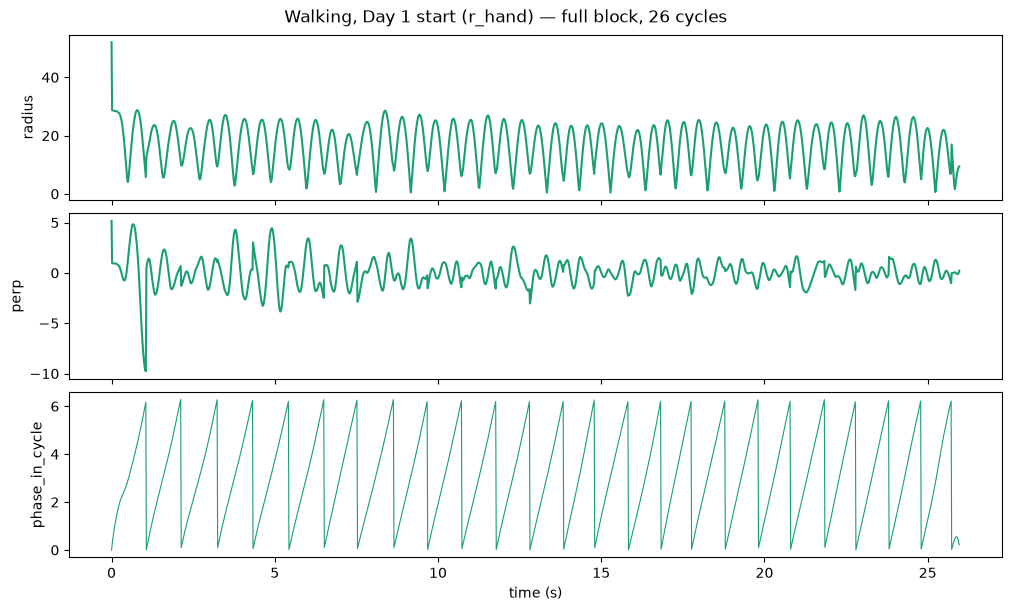

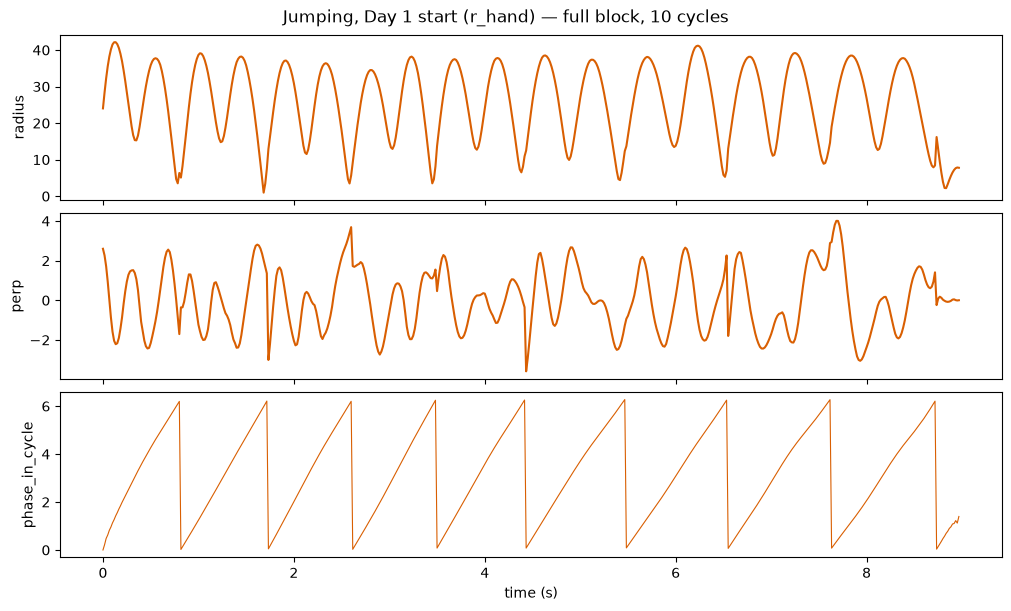

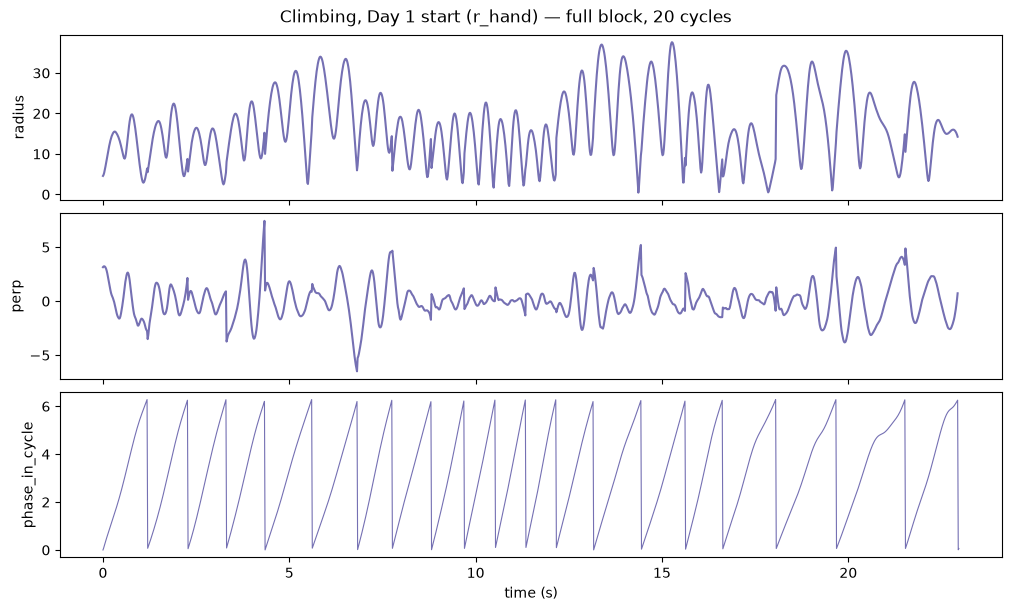

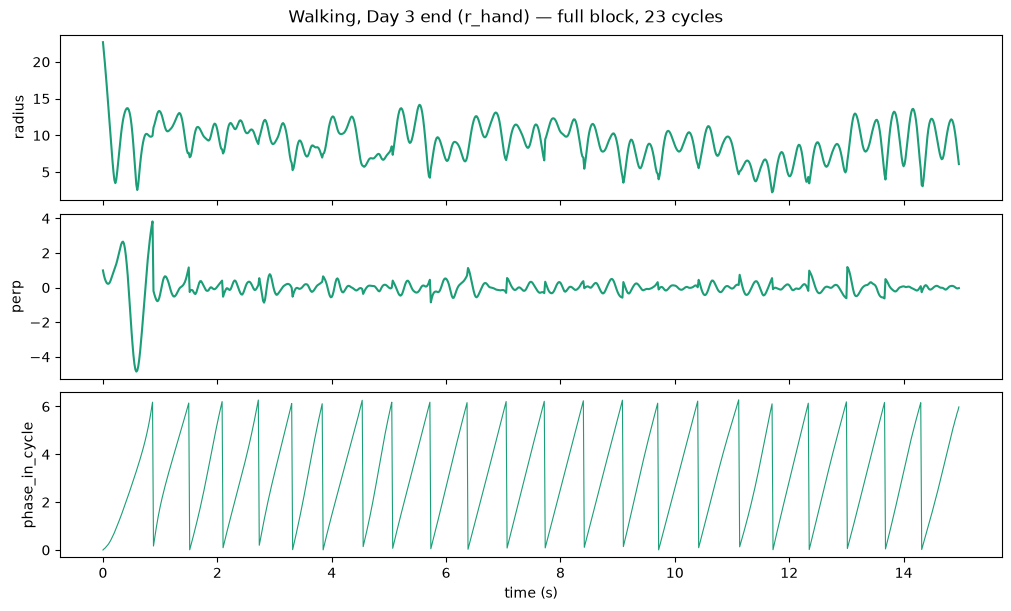

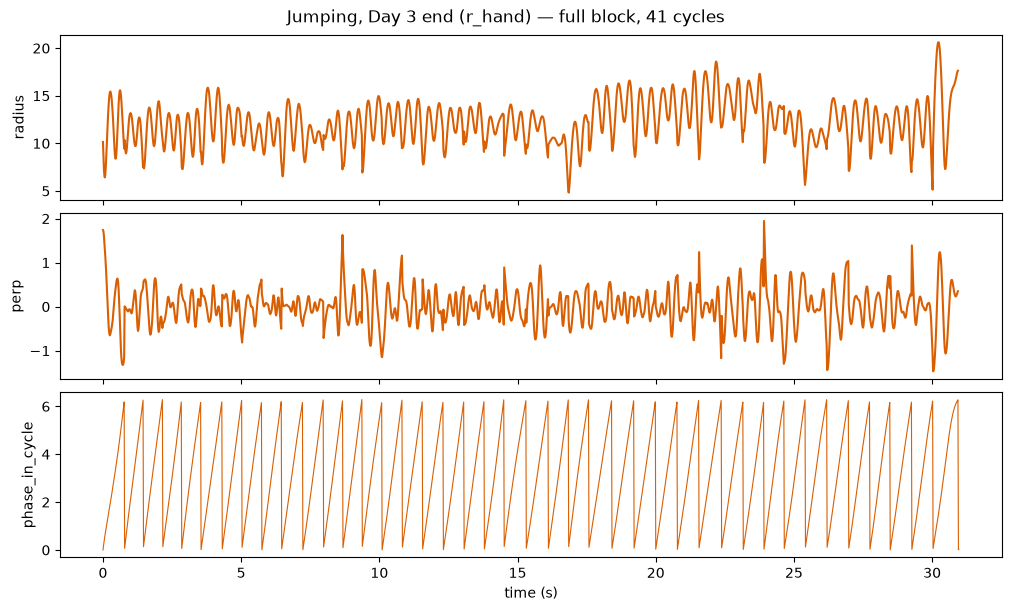

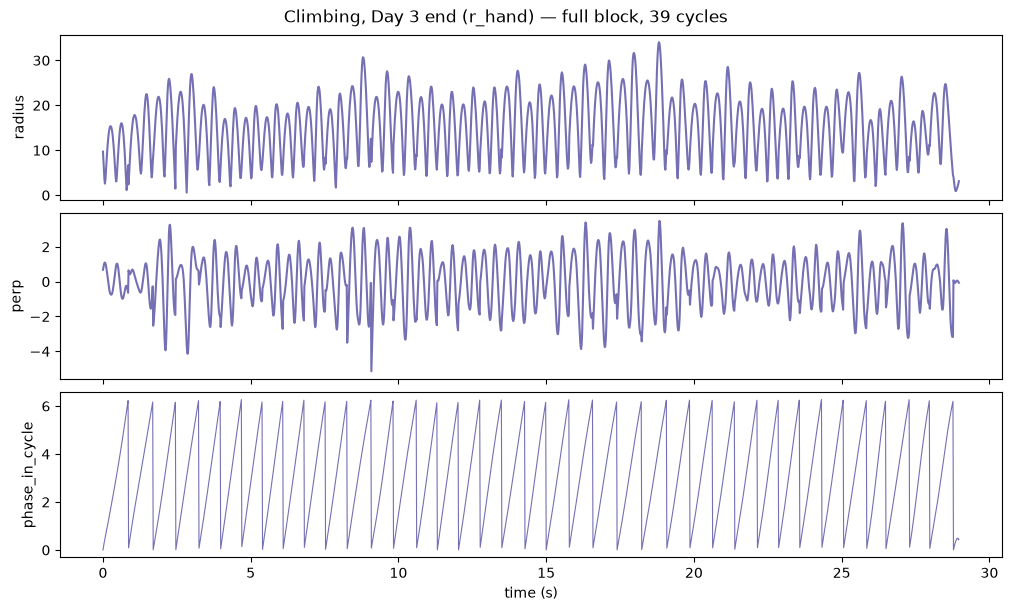

In [9]:
def plot_block_signals(cond, key):
    entry = CACHE[key]
    samples = entry["samples"]
    day, part, skill = cond
    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True, constrained_layout=True)
    color = pl.SKILL_COLORS[skill]
    axes[0].plot(samples["time"], samples["radius"], color=color)
    axes[0].set_ylabel("radius")
    axes[1].plot(samples["time"], samples["perp"], color=color)
    axes[1].set_ylabel("perp")
    axes[2].plot(samples["time"], samples["phase_in_cycle"], color=color, lw=0.8)
    axes[2].set_ylabel("phase_in_cycle")
    axes[2].set_xlabel("time (s)")
    fig.suptitle(f"{pl.SKILL_LABELS[skill]}, {pl.DAY_LABELS[day]} {pl.PART_LABELS[part]} "
                 f"({PRIMARY_HAND}) — full block, {entry['meta']['n_cycles']} cycles")
    pl.save_figure(fig, f"stage4_signals_{skill}_day{day}{part}")
    plt.show()

for cond, key in PRIMARY_KEYS.items():
    plot_block_signals(cond, key)

## Subphase 5a — within-block drift & variability (cycle-to-cycle)

For each primary block: cycle duration, distance of each cycle's plane center from the
block-mean center, angular deviation of each cycle's normal from the block-mean normal,
`radius_mean`, and `perp_sd` (within-cycle off-plane *width* -- `perp_mean` is omitted since it is ~0 for every cycle by construction: PCA mean-centering guarantees the 3rd component's mean is exactly zero over the points it was fit to; `perp_sd` is the metric that actually carries information), all plotted against cycle index. One combined grid
(rows = condition, columns = metric) rather than 30 separate figures.

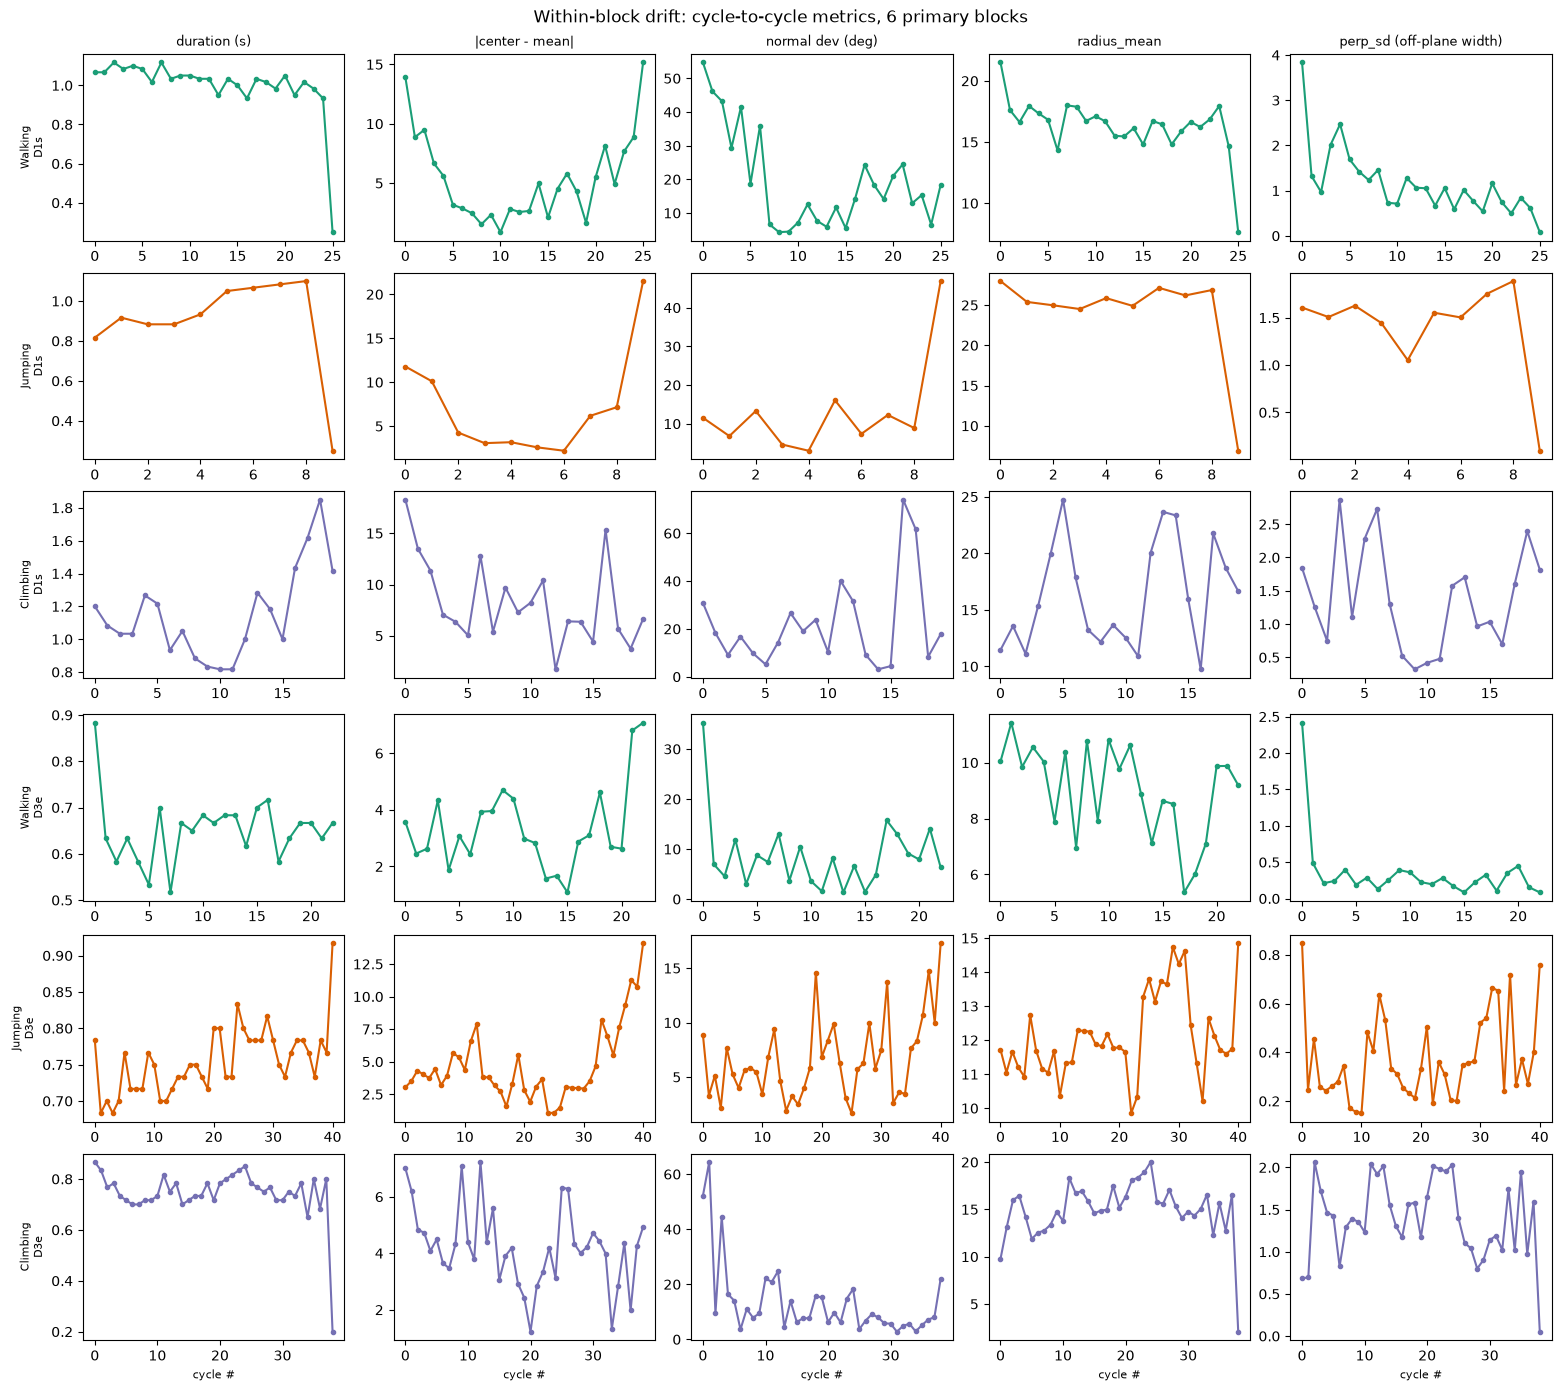

In [10]:
def within_block_metrics(cycles):
    ok = cycles[cycles.fit_ok].reset_index(drop=True)
    centers = ok[["center_x", "center_y", "center_z"]].to_numpy()
    normals = ok[["normal_x", "normal_y", "normal_z"]].to_numpy()
    mean_center = centers.mean(axis=0)
    mean_normal = normals.mean(axis=0)
    mean_normal = mean_normal / max(np.linalg.norm(mean_normal), 1e-12)
    center_dist = np.linalg.norm(centers - mean_center, axis=1)
    cos = np.clip((normals * mean_normal).sum(axis=1), -1, 1)
    normal_dev_deg = np.degrees(np.arccos(np.abs(cos)))
    return ok.assign(center_dist=center_dist, normal_dev_deg=normal_dev_deg)

METRICS = ["duration", "center_dist", "normal_dev_deg", "radius_mean", "perp_sd"]
METRIC_LABELS = {"duration": "duration (s)", "center_dist": "|center - mean|",
                  "normal_dev_deg": "normal dev (deg)", "radius_mean": "radius_mean",
                  "perp_sd": "perp_sd (off-plane width)"}

fig, axes = plt.subplots(len(CONDITIONS), len(METRICS), figsize=(3.1 * len(METRICS), 2.3 * len(CONDITIONS)),
                          constrained_layout=True)
for row, (cond, key) in enumerate(PRIMARY_KEYS.items()):
    day, part, skill = cond
    m = within_block_metrics(CACHE[key]["cycles"])
    for col, metric in enumerate(METRICS):
        ax = axes[row, col]
        ax.plot(m["cycle"], m[metric], "o-", color=pl.SKILL_COLORS[skill], ms=3)
        if row == 0:
            ax.set_title(METRIC_LABELS[metric], fontsize=9)
        if col == 0:
            ax.set_ylabel(f"{pl.SKILL_LABELS[skill]}\nD{day}{part}", fontsize=8)
        if row == len(CONDITIONS) - 1:
            ax.set_xlabel("cycle #", fontsize=8)
fig.suptitle("Within-block drift: cycle-to-cycle metrics, 6 primary blocks")
pl.save_figure(fig, "stage5_within_block_drift_grid")
plt.show()

## Subphase 5b — across-run variability, day 1 (start) vs day 3 (end)

Using all 58 disjoint runs (not just the 6 primary blocks) as real bout-to-bout replicate
data: for every run, take the run-level mean of each metric across its own cycles, then
compare the spread of those per-run means across day-1-start vs day-3-end, per skill.
This shows whether a typical *bout* looks different late in practice, and whether
bout-to-bout variability itself changes with practice.

           count       mean
skill day                  
climb 1       11  10.636364
      3        6  33.500000
jump  1       13   8.000000
      3        7  29.000000
walk  1       11  11.000000
      3       10  19.500000


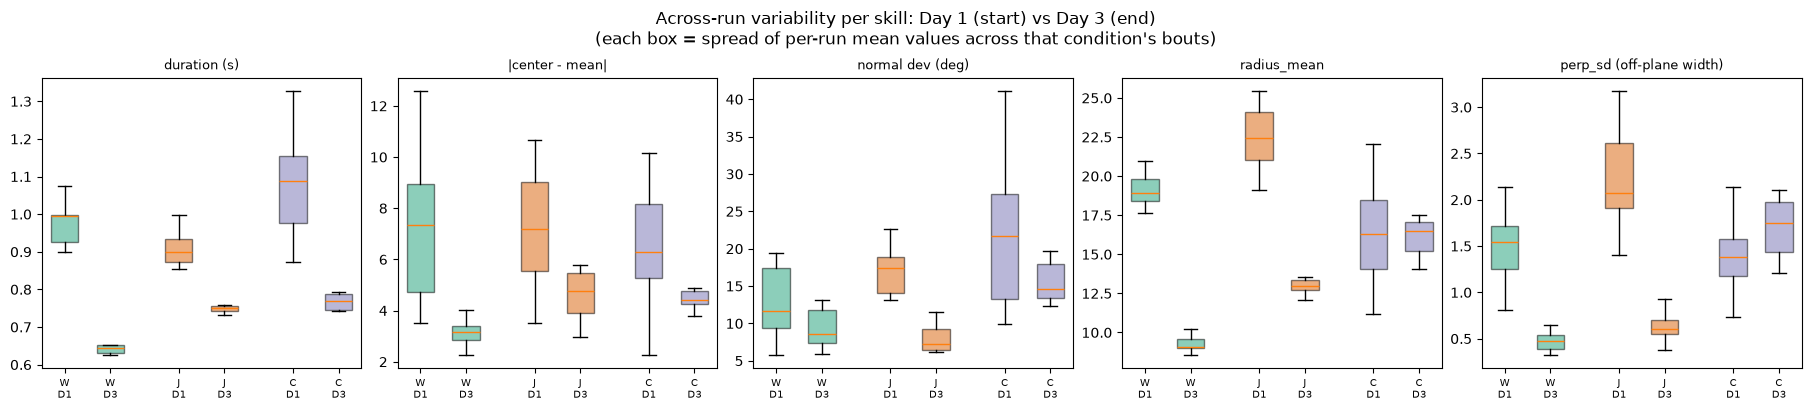

In [11]:
def run_level_summary(key):
    cycles = CACHE[key]["cycles"]
    ok = cycles[cycles.fit_ok]
    if len(ok) == 0:
        return None
    m = within_block_metrics(cycles)
    subject, day, part, skill, source_file, run_id, hand = key
    return {"day": day, "part": part, "skill": skill, "hand": hand, "run_id": run_id,
            "n_cycles": len(ok), "duration": m["duration"].mean(),
            "center_dist": m["center_dist"].mean(), "normal_dev_deg": m["normal_dev_deg"].mean(),
            "radius_mean": m["radius_mean"].mean(), "perp_sd": m["perp_sd"].mean()}

RUN_SUMMARY = pd.DataFrame([r for k in CACHE if (r := run_level_summary(k)) is not None])
RUN_SUMMARY = RUN_SUMMARY[RUN_SUMMARY.hand == PRIMARY_HAND]  # avoid double-counting both hands
print(RUN_SUMMARY.groupby(["skill", "day"])["n_cycles"].agg(["count", "mean"]))

SKILLS = ["walk", "jump", "climb"]
DAYS = [1, 3]
fig, axes = plt.subplots(1, len(METRICS), figsize=(3.6 * len(METRICS), 4), constrained_layout=True)
for col, metric in enumerate(METRICS):
    ax = axes[col]
    positions, data, colors = [], [], []
    labels = []
    pos = 0
    for skill in SKILLS:
        for day in DAYS:
            vals = RUN_SUMMARY[(RUN_SUMMARY.skill == skill) & (RUN_SUMMARY.day == day)][metric].dropna()
            positions.append(pos); data.append(vals.to_numpy()); colors.append(pl.SKILL_COLORS[skill])
            labels.append(f"{skill[0].upper()}\nD{day}")
            pos += 1
        pos += 0.5
    bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True, showfliers=False)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.5)
    ax.set_xticks(positions); ax.set_xticklabels(labels, fontsize=7)
    ax.set_title(METRIC_LABELS[metric], fontsize=9)
fig.suptitle("Across-run variability per skill: Day 1 (start) vs Day 3 (end)\n"
             "(each box = spread of per-run mean values across that condition's bouts)")
pl.save_figure(fig, "stage5_across_run_day1_vs_day3")
plt.show()

## Summary

This cell prints the numbers behind the two subphase-5 figures for the record (median
per-run values by condition, and whether day-3 spread is larger/smaller than day-1).

In [12]:
summary_table = RUN_SUMMARY.groupby(["skill", "day"])[METRICS].agg(["median", "std"]).round(4)
summary_table

duration         center_dist         normal_dev_deg           \
            median     std      median     std         median      std   
skill day                                                                
climb 1     1.0894  0.1352      6.2916  2.2186        21.7274  10.2466   
      3     0.7685  0.0235      4.4232  0.4135        14.6732   3.0180   
jump  1     0.8983  0.0527      7.2039  2.3146        17.3635   5.6568   
      3     0.7494  0.0279      4.7557  1.8607         7.2623   2.1054   
walk  1     0.9958  0.0568      7.3375  3.0151        11.7184  11.4486   
      3     0.6442  0.0216      3.1518  0.8656         8.5697   2.7045   

          radius_mean         perp_sd          
               median     std  median     std  
skill day                                      
climb 1       16.3202  3.4563  1.3839  0.3931  
      3       16.4725  1.3722  1.7536  0.3602  
jump  1       22.4245  1.8830  2.0714  0.5295  
      3       12.9504  0.7142  0.6080  0.1799  
walk  1       18.9504  1.2640  1.5392  0.3676  
      3        9.0795  0.4744  0.4800  0.1043